# Williams Alligator -- does the waking alligator catch trends?
### A famous three-line trend indicator, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Catches_trends%3F: Not_supported](https://img.shields.io/badge/Catches_trends%3F-Not_supported-8b949e?style=flat-square)

Bill Williams' *Alligator* is three coloured moving averages -- a blue **Jaw**, a red **Teeth**, a green **Lips** -- plotted on the chart and shifted forward in time. The story is vivid: when the lines twist together the *'alligator sleeps'* (no trend -- stay out); when they fan apart in order the *'alligator wakes and eats'* -- a trend has started, climb aboard and ride it. This notebook asks the only question that matters: does the waking alligator actually catch trends -- better than just buying and holding, and better than a plain 200-day average?

> **This is the plain-language layer.** Want the HAC *t*-stats, the permutation placebo and the benchmark race? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from williams_alligator import data, strategy as st

TICKER = "SPY"
SMA_N  = 200
TBILL  = 0.04 / 252.0   # flat 4%/yr daily proxy
COST   = 5.0             # one-way bps on NAV
BORROW = 50.0           # annual borrow on the short leg
END    = "2026-06-23"   # pin to last complete trading day

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-24).
R = dict(
    n=8406, start="1993-01-29", end="2026-06-23", fp="6e7b9258f0b0",
    in_pos_lf=59.1, n_changes_lf=497,
    bh_cagr=10.78, bh_sharpe=0.551, bh_vol=18.59, bh_dd=-55.19, bh_t=3.66,
    al_cagr=6.46, al_sharpe=0.593, al_vol=10.56, al_dd=-20.37, al_t=3.79,
    sma_cagr=9.12, sma_sharpe=0.726, sma_vol=12.01, sma_dd=-21.91, sma_t=4.50,
    t_allig_vs_bh=-1.71, t_allig_vs_sma=-1.61, placebo_p=0.151, placebo_obs=0.042,
    in_pos_ls=82.8, n_changes_ls=873,
    als_cagr=2.69, als_sharpe=0.156, als_vol=17.03, als_dd=-37.48, als_t=1.05,
    t_alligls_vs_bh=-1.85,
    sharpe_0bps=0.664, sharpe_1bps=0.650, sharpe_5bps=0.593,
    sharpe_10bps=0.522, sharpe_25bps=0.309,
    syn_null_bh=0.179, syn_null_al=0.357, syn_null_alt=1.44, syn_null_difft=0.42,
    syn_trend_bh=-0.130, syn_trend_al=1.999, syn_trend_alt=6.97, syn_trend_difft=4.75,
)

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    bars   = data.load_real(TICKER).loc[:END]
    sig_lf = st.alligator_signal(bars, mode="long_flat")
    sig_sm = st.sma_signal(bars, n=SMA_N, mode="long_flat")
    bt_a   = st.run_backtest(bars, sig_lf, tbill_daily=TBILL, cost_bps=COST, borrow_bps_ann=BORROW)
    bt_s   = st.run_backtest(bars, sig_sm, tbill_daily=TBILL, cost_bps=COST, borrow_bps_ann=BORROW)
    s_bh   = st.summary(bt_a["r_bh"])
    s_al   = st.summary(bt_a["r_strategy"])
    s_sm   = st.summary(bt_s["r_strategy"])
    in_pos = float((sig_lf.abs() > 0).mean())
else:
    bars = None
    s_bh = dict(cagr=R["bh_cagr"]/100, sharpe=R["bh_sharpe"], max_drawdown=R["bh_dd"]/100, vol_ann=R["bh_vol"]/100)
    s_al = dict(cagr=R["al_cagr"]/100, sharpe=R["al_sharpe"], max_drawdown=R["al_dd"]/100, vol_ann=R["al_vol"]/100)
    s_sm = dict(cagr=R["sma_cagr"]/100, sharpe=R["sma_sharpe"], max_drawdown=R["sma_dd"]/100, vol_ann=R["sma_vol"]/100)
    in_pos = R["in_pos_lf"]/100
    bt_a = bt_s = sig_lf = None


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the Alligator beat buy-and-hold? | **Not on return.** Its long/flat CAGR is **+6.5%** vs buy-and-hold's **+10.8%**. Its Sharpe is a hair higher (0.593 vs 0.551) -- but only because it sits in cash half the time, cutting *volatility*, not because it times anything. |
| Is that 'higher Sharpe' statistically real? | **No.** The Sharpe-difference *t* vs buy-and-hold is **-1.71** -- below the |*t*| = 2 bar (and negative: the rule earns *less* mean return). A block-shuffle placebo beats it **15%** of the time. |
| Is the fancy three-line machinery worth it? | **No.** A plain **200-day moving average** -- one line -- gets a *higher* Sharpe (0.726 vs 0.593) with fewer trades. The Alligator is beaten by the simplest trend rule there is. |
| Could you trade it? | **It would cost you.** It changes position ~15 times a year, and net of costs it lags buy-and-hold on return while only matching the simpler rule on risk. |

> The waking alligator does *one* real thing -- it ducks the worst of the big crashes, the same way any slow trend filter does. But it does it *worse* than a single 200-day average, and it never delivers the 'catch the trend, beat the market' payoff the folklore promises. **Weak signal, mirage tradability, trend-catching not supported.**

## 1 -- The claim

> *'The Alligator is essentially three balance lines... When the Alligator's mouth is closed or has closed, it is sleeping... As it sleeps, it gets hungrier and hungrier. When it awakens, it opens its mouth (the lines diverge) and begins to eat -- and the trend begins. Ride it until the lines start to come back together.'*
> -- after Bill Williams, *Trading Chaos* (1995)

The three lines are smoothed moving averages of the day's **median price** (the midpoint of the high and low), each pushed forward in time:

- **Jaw** (blue) = 13-period smoothed average, shifted 8 bars forward.
- **Teeth** (red) = 8-period, shifted 5 bars.
- **Lips** (green) = 5-period, shifted 3 bars.

When **Lips > Teeth > Jaw** the lines fan out bullishly (the green leads, the blue lags) -- an uptrend, go long. The reverse is a downtrend. When they're tangled, the alligator sleeps -- stay flat. It's a clean, visual trend filter, and it is taught in thousands of YouTube tutorials and built into every charting platform.

## 2 -- So what?

If the Alligator genuinely caught trends, it would be worth a fortune: you'd capture the big up-moves, sidestep the crashes, and beat a passive index on *both* return and risk. That is exactly what its fans claim. And it has a plausible-sounding logic -- the three different look-backs are supposed to confirm each other, so you only commit when fast, medium and slow trends all agree.

But there's a simpler explanation lurking. *Any* rule that goes to cash during sustained downtrends will dodge crashes and look good on a volatility-adjusted basis -- not because it's clever, but because it's out of the market when the market falls hardest. The real test isn't 'does it beat buy-and-hold's Sharpe?' (lots of dull rules do that by cutting exposure). It's: **does the alligator's special machinery beat the dumbest possible trend filter -- a single moving average?**

## 3 -- How would we even know?

Three honest tests, announced before we run them:

1. **Race it against buy-and-hold AND against a plain 200-day average.** Same engine, same costs, same one-day execution lag. If the Alligator can't beat a one-line moving average, its three-line ceremony is decoration.
2. **The placebo.** Keep the alligator's in/out *pattern* but scramble its *timing* (rotate the signal in blocks). If a scrambled version beats buy-and-hold about as often as the real one, the 'timing' is luck.
3. **The synthetic control.** Build a fake market with *real, planted* multi-week trends and confirm the engine *can* catch them when they exist -- so a null result on the real tape means 'no trend to catch', not 'broken test'.

**What would make us say 'mirage':** the Alligator fails to clear |*t*| = 2 against buy-and-hold, *and* a plain moving average does as well or better.

## 4 -- The teardown -- let's actually look

**First, what the three lines and the signal look like on a slice of real SPY:**

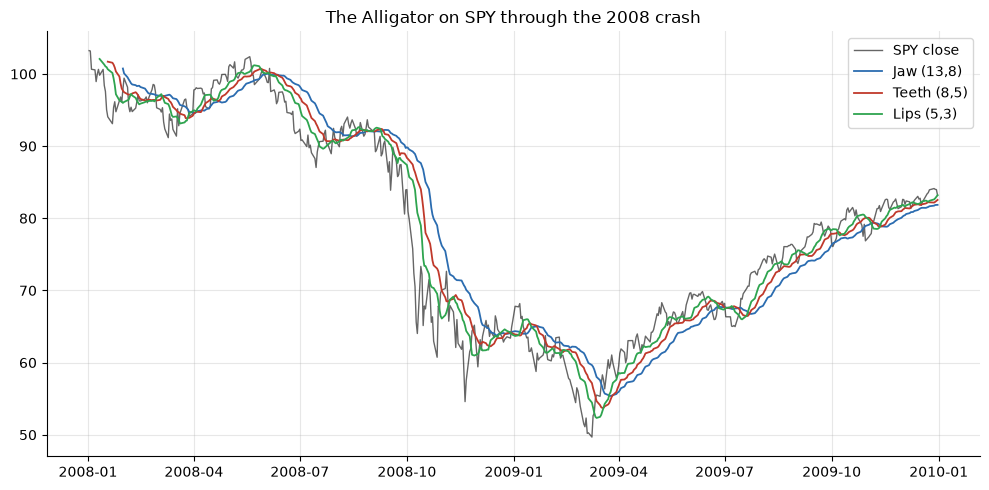

In [2]:
if HAVE_REAL:
    win = bars.loc['2008-01-01':'2009-12-31']
    a = st.alligator(win)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(win.index, win['close'], c='black', lw=1.0, alpha=.6, label='SPY close')
    ax.plot(a.index, a['jaw'],   c='#2b6cb0', lw=1.3, label='Jaw (13,8)')
    ax.plot(a.index, a['teeth'], c=RED,       lw=1.3, label='Teeth (8,5)')
    ax.plot(a.index, a['lips'],  c=GREEN,     lw=1.3, label='Lips (5,3)')
    ax.set_title('The Alligator on SPY through the 2008 crash'); ax.legend(loc='upper right')
else:
    fig, ax = plt.subplots(); ax.text(.5,.5,'cache not present',ha='center')
plt.tight_layout(); plt.show()


Through 2008 the lines fan out *downward* (green Lips dives below red Teeth below blue Jaw) -- the long/flat rule reads that as 'not bullish' and steps to cash, dodging much of the crash. That's the one thing it does well. Now the scorecard.

**The three-way race: buy-and-hold vs Alligator vs a plain 200-day average.**

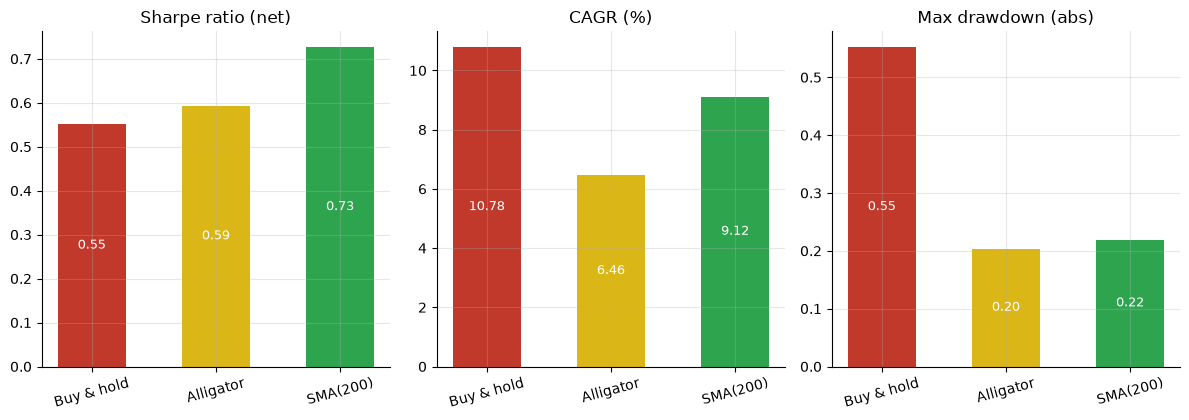

Alligator Sharpe 0.593 vs SMA(200) 0.726 vs B&H 0.551


In [3]:
labels = ['Buy & hold', 'Alligator', 'SMA(200)']
sharpes = [s_bh['sharpe'], s_al['sharpe'], s_sm['sharpe']]
cagrs   = [s_bh['cagr']*100, s_al['cagr']*100, s_sm['cagr']*100]
dds     = [abs(s_bh['max_drawdown']), abs(s_al['max_drawdown']), abs(s_sm['max_drawdown'])]
colors  = [RED, AMBER, GREEN]
fig, ax = plt.subplots(1, 3, figsize=(12, 4.3))
for i, (vals, title) in enumerate([(sharpes,'Sharpe ratio (net)'),
                                   (cagrs,'CAGR (%)'), (dds,'Max drawdown (abs)')]):
    bars_ = ax[i].bar(labels, vals, color=colors, width=.55)
    for b, v in zip(bars_, vals):
        ax[i].annotate(f'{v:.2f}', (b.get_x()+b.get_width()/2, v/2),
                       ha='center', va='center', color='white', fontsize=9)
    ax[i].set_title(title); ax[i].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print(f'Alligator Sharpe {s_al["sharpe"]:.3f} vs SMA(200) {s_sm["sharpe"]:.3f} vs B&H {s_bh["sharpe"]:.3f}')


The punchline in one picture: the Alligator's Sharpe (0.593) edges out buy-and-hold (0.551) only by giving up a third of the return -- and the dead-simple 200-day average (0.726) beats *both*, with a higher CAGR than the Alligator too. The fancy three-line machinery loses to a single line.

## 5 -- The verdict

- **Signal -- WEAK.** The Alligator's edge over buy-and-hold doesn't clear the bar (Sharpe-difference *t* = -1.71, placebo *p* = 0.15). Its only real effect is vol/drawdown reduction -- which any slow trend filter delivers.
- **Tradability -- MIRAGE.** Net of costs it earns *less* than buy-and-hold, and it is strictly dominated by a one-line 200-day average on every axis that matters. Paying for three displaced lines buys you nothing.
- **Catches trends? -- NOT SUPPORTED.** It catches *crashes* (by being out), not trends (by being in at the right time). The 'wake and eat' story isn't what the tape shows.

## 6 -- Could you actually trade it?

The Alligator changes position about 15 times a year. Here's what costs do to it:

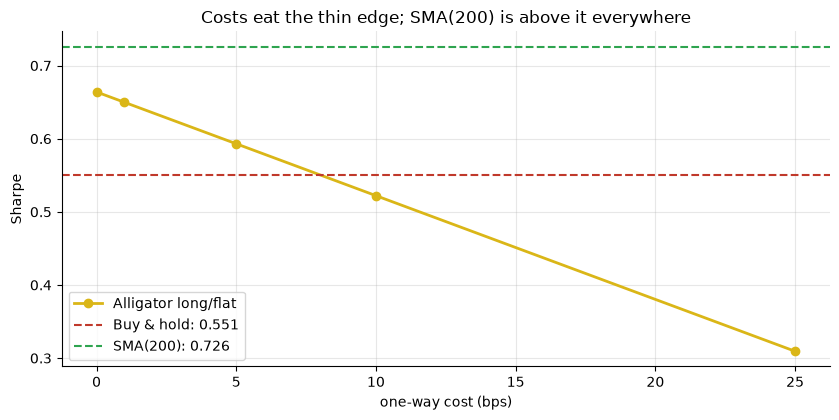

At 5 bps: Alligator 0.593, below SMA(200) 0.726 the whole way


In [4]:
if HAVE_REAL:
    costs = [0.0, 1.0, 5.0, 10.0, 25.0]; shs = []
    for c in costs:
        bt_c = st.run_backtest(bars, sig_lf, tbill_daily=TBILL, cost_bps=c, borrow_bps_ann=BORROW)
        shs.append(st.summary(bt_c['r_strategy'])['sharpe'])
else:
    costs = [0.0,1.0,5.0,10.0,25.0]
    shs = [R['sharpe_0bps'],R['sharpe_1bps'],R['sharpe_5bps'],R['sharpe_10bps'],R['sharpe_25bps']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, shs, 'o-', c=AMBER, lw=2, label='Alligator long/flat')
ax.axhline(R['bh_sharpe'], ls='--', c=RED, label=f"Buy & hold: {R['bh_sharpe']:.3f}")
ax.axhline(R['sma_sharpe'], ls='--', c=GREEN, label=f"SMA(200): {R['sma_sharpe']:.3f}")
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('Sharpe'); ax.legend()
ax.set_title('Costs eat the thin edge; SMA(200) is above it everywhere')
plt.tight_layout(); plt.show()
print(f'At 5 bps: Alligator {shs[2]:.3f}, below SMA(200) {R["sma_sharpe"]:.3f} the whole way')


At realistic ETF costs (5 bps one-way) the Alligator's Sharpe is 0.593 -- already below the SMA(200) line (0.726), and it falls fast as costs rise. There is no cost level at which the Alligator is the best choice on this tape.

## 7 -- Going further

- **Add Williams' filters.** The full *Trading Chaos* system layers the Alligator with the *Awesome Oscillator* and *fractals*. A fork could test whether those add real timing on top -- our prior on multi-filter TA systems is low, but it's testable.
- **Other instruments / faster bars.** The Alligator is popular on FX and crypto. The engine here takes any OHLC tape -- run it on BTC or EURUSD and see if a trendier asset rescues it.
- **Compare to the desk's other trend filters.** [Study 110 (Faber-Timing)](../../110-faber-timing/) is the SMA(200) benchmark that beats the Alligator here; [Study 106 (Supertrend)](../../106-supertrend/) is another lagging-band flip rule. Same family, same disappointment.

*Think the alligator has teeth we missed? Fork it, add the Awesome Oscillator and fractal filters, and show a real-tape Sharpe-difference *t* over 2 against SMA(200). That's the bar.*